<a href="https://colab.research.google.com/github/devikarnambigai086-rgb/Oasis-Infobyte-DataScience-Internship/blob/main/Task5_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (10).zip to archive (10).zip


# Task 5: Sales Prediction using Python
### Oasis Infobyte Data Science Internship

This notebook predicts product sales based on advertising expenditure
across TV, Radio, and Newspaper channels using regression models.

**Dataset:** Advertising.csv  
**Libraries:** Pandas, Matplotlib, Seaborn, Scikit-learn

In [ ]:
import zipfile
import os

with zipfile.ZipFile("archive (10).zip", 'r') as zip_ref:
    zip_ref.extractall("sales_data")

print(os.listdir("sales_data"))

['advertising.csv']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_data/advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


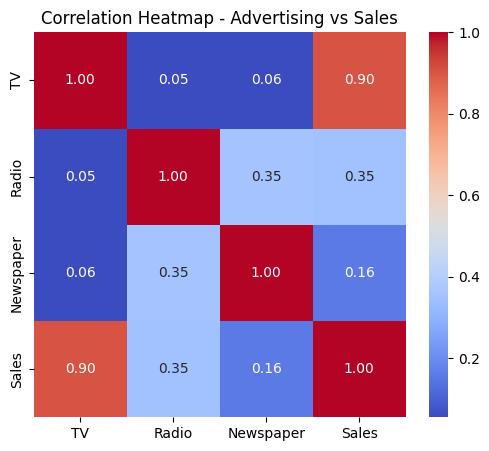

In [ ]:
# Check for missing values and data info
print(df.isnull().sum())
df.info()

# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Advertising vs Sales')
plt.show()

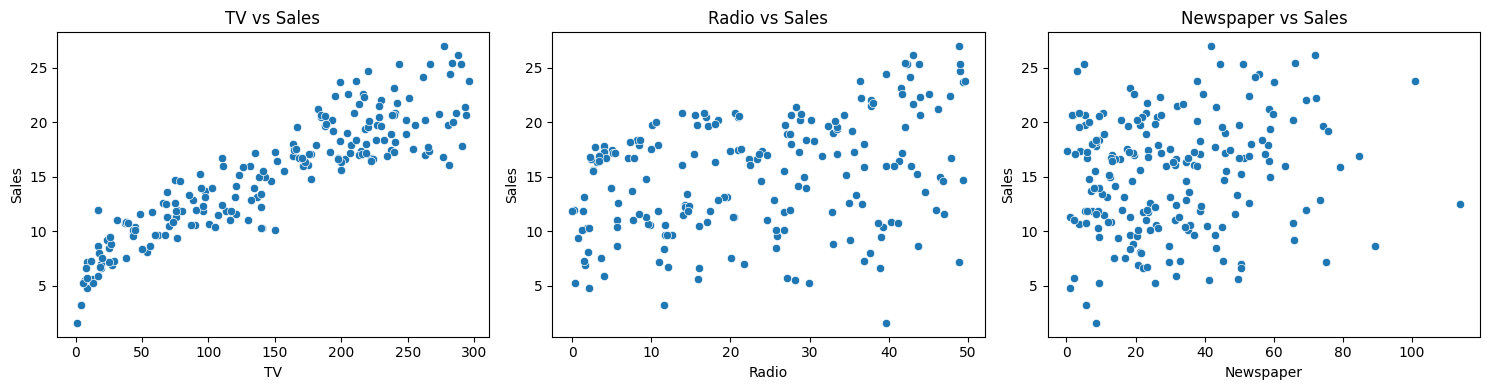

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0])
sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1])
sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[2])
axes[0].set_title('TV vs Sales')
axes[1].set_title('Radio vs Sales')
axes[2].set_title('Newspaper vs Sales')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("\nCoefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef:.4f}")

R² Score: 0.9059011844150826
Mean Squared Error: 2.9077569102710896

Coefficients:
TV: 0.0545
Radio: 0.1009
Newspaper: 0.0043


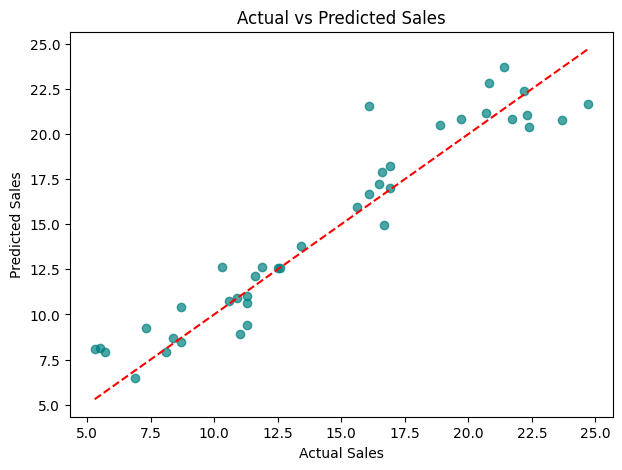

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

## Key Insights

1. **TV is the strongest driver:** TV advertising shows the highest
   correlation with sales (0.90), significantly outperforming Radio (0.35)
   and Newspaper (0.16).

2. **Model Performance:** The Linear Regression model achieved an
   R² score of 0.906, meaning it explains ~91% of the variance in sales —
   a strong predictive fit.

3. **Channel Impact (Coefficients):**
   - Radio has the highest per-unit impact (0.1009) on sales
   - TV follows closely (0.0545)
   - Newspaper has minimal impact (0.0043)

## Conclusion
Businesses should prioritize TV and Radio advertising budgets over
Newspaper for maximum sales impact. The regression model provides a
reliable tool for forecasting sales based on advertising spend allocation.

---
**Tools used:** Python, Pandas, Seaborn, Scikit-learn (Linear Regression)  
**Internship:** Oasis Infobyte Data Science Internship — Task 5